#  Primetrade.ai - Data Science Intern Asssignment

## Objective

To analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid. Your goal is to uncover patterns that could inform smarter trading strategies.


## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Part A — Data preparation

In [2]:
# Load Bitcoin Market Sentiment (Fear/Greed) data
sentiment_df = pd.read_csv('fear_greed_index.csv')
print(sentiment_df.shape)
sentiment_df.head()

(2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [3]:
# Load Historical Trader Data (Hyperliquid) data
trader_df = pd.read_csv('historical_data.csv')
print(trader_df.shape)
trader_df.head()

(211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


### To check missing and duplicated values for both datasets

In [4]:
print('Sentiment Data')
print('Shape(rows & columns):', sentiment_df.shape)
print('Missing values:\n', sentiment_df.isnull().sum())
print('Duplicates:', sentiment_df.duplicated().sum())

Sentiment Data
Shape(rows & columns): (2644, 4)
Missing values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicates: 0


In [5]:
print('Trades Data')
print('Shape(rows & columns):', trader_df.shape)
print('Missing values:\n', trader_df.isnull().sum())
print('Duplicates:', trader_df.duplicated().sum())

Trades Data
Shape(rows & columns): (211224, 16)
Missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicates: 0


we can see that there is no missing and duplicate values in both datasets.

### Q2

to convert into datetime and grp trader dataset as daywise.

In [6]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

In [7]:
trader_df['date'] = pd.to_datetime(trader_df['Timestamp IST'],format='%d-%m-%Y %H:%M').dt.date
trader_df['date'] = pd.to_datetime(trader_df['date'])

In [8]:
daily_trader = trader_df.groupby('date').agg(
    total_trades   = ('Trade ID',   'count'),
    total_size_usd = ('Size USD',   'sum'),
    total_pnl      = ('Closed PnL', 'sum'),
    buy_count      = ('Side', lambda x: (x == 'BUY').sum()),
    sell_count     = ('Side', lambda x: (x == 'SELL').sum())
).reset_index()

In [9]:
daily_trader

,date,total_trades,total_size_usd,total_pnl,buy_count,sell_count
0,2023-05-01,3,477.00,0.000000,3,0
1,2023-12-05,9,50005.83,0.000000,7,2
2,2023-12-14,11,113203.35,-205.434737,5,6
3,2023-12-15,2,10609.95,-24.632034,2,0
4,2023-12-16,3,15348.77,0.000000,3,0
...,...,...,...,...,...,...
475,2025-04-27,337,487537.69,2702.067468,209,128
476,2025-04-28,1379,26124921.49,36906.813759,652,727
477,2025-04-29,2243,34089511.66,125749.613427,1105,1138
478,2025-04-30,1113,12693878.85,14003.797269,838,275


In [10]:
print("rows&columns after grouping:",daily_trader.shape)
daily_trader.head()

rows&columns after grouping: (480, 6)


,date,total_trades,total_size_usd,total_pnl,buy_count,sell_count
0,2023-05-01,3,477.00,0.000000,3,0
1,2023-12-05,9,50005.83,0.000000,7,2
2,2023-12-14,11,113203.35,-205.434737,5,6
3,2023-12-15,2,10609.95,-24.632034,2,0
4,2023-12-16,3,15348.77,0.000000,3,0


what we can see is that trader dataset is not having daily rows. i.e there are missing data for some days

In [11]:
print("Fear/Greed date range:", sentiment_df['date'].min(), "to", sentiment_df['date'].max())
print("Trader date range:     ", daily_trader['date'].min(), "to", daily_trader['date'].max())

Fear/Greed date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00
Trader date range:      2023-05-01 00:00:00 to 2025-05-01 00:00:00


### merged datasets

In [12]:
merged_df = trader_df.merge(sentiment_df[['date', 'value', 'classification']], on='date', how='inner')

print(merged_df.shape)
print(merged_df['classification'].value_counts())

(211218, 19)
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [13]:
# Create a full continuous date range from start to end
full_date_range = pd.date_range(start='2023-05-01', end='2025-05-01', freq='D')

# Check which dates are missing from trader data
missing_dates = full_date_range.difference(merged_df['date'])

print("Total days expected:", len(full_date_range))
print("Total days in trader data:", len(merged_df))
print("Missing days:", len(missing_dates))
print("\nSample missing dates:\n", missing_dates[:10])

Total days expected: 732
Total days in trader data: 211218
Missing days: 253

Sample missing dates:
 DatetimeIndex(['2023-05-02', '2023-05-03', '2023-05-04', '2023-05-05',
               '2023-05-06', '2023-05-07', '2023-05-08', '2023-05-09',
               '2023-05-10', '2023-05-11'],
              dtype='datetime64[ns]', freq=None)


In [14]:
missing_dates

DatetimeIndex(['2023-05-02', '2023-05-03', '2023-05-04', '2023-05-05',
               '2023-05-06', '2023-05-07', '2023-05-08', '2023-05-09',
               '2023-05-10', '2023-05-11',
               ...
               '2024-09-03', '2024-09-07', '2024-09-12', '2024-09-13',
               '2024-09-15', '2024-09-16', '2024-09-17', '2024-09-29',
               '2024-10-24', '2024-10-26'],
              dtype='datetime64[ns]', length=253, freq=None)

In [15]:
missing_df = pd.DataFrame({'date': missing_dates})
missing_df['month'] = missing_df['date'].dt.to_period('M')  # gives "2023-05", "2023-06" etc

print(missing_df['month'].value_counts().sort_index())

month
2023-05    30
2023-06    30
2023-07    31
2023-08    31
2023-09    30
2023-10    31
2023-11    30
2023-12    14
2024-01     3
2024-02     3
2024-03     3
2024-04     2
2024-05     3
2024-06     1
2024-08     1
2024-09     8
2024-10     2
Freq: M, Name: count, dtype: int64


here we can see months of year 2023 (may,june,july,august,sept,oct,nov) is not having any data.

"Trader data prior to 2024 was significantly sparse, with 80–100% of days missing per month. Therefore, analysis was restricted to January 2024 onwards to ensure data consistency."

In [16]:
# Simply start from 2024 where data is consistent
merged_df = merged_df[merged_df['date'] >= '2024-01-01']
#sentiment_df = sentiment_df[sentiment_df['date'] >= '2024-01-01']

### Q3

In [17]:
print(merged_df.columns.tolist())
print(merged_df.dtypes)

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'value', 'classification']
Account                     object
Coin                        object
Execution Price            float64
Size Tokens                float64
Size USD                   float64
Side                        object
Timestamp IST               object
Start Position             float64
Direction                   object
Closed PnL                 float64
Transaction Hash            object
Order ID                     int64
Crossed                       bool
Fee                        float64
Trade ID                   float64
Timestamp                  float64
date                datetime64[ns]
value                        int64
classification              object
dtype: object


In [18]:
# Win flag
merged_df['is_win'] = merged_df['Closed PnL'] > 0

In [19]:
# Leverage
merged_df['leverage'] = (merged_df['Size USD'] /merged_df['Start Position'].replace(0, float('nan'))).round(2)

In [20]:
# Leverage category
def categorize_leverage(lev):
    if lev <= 2:    return 'Low (1-2x)'
    elif lev <= 5:  return 'Medium (2-5x)'
    elif lev <= 10: return 'High (5-10x)'
    else:           return 'Very High (10x+)'

merged_df['leverage_category'] = merged_df['leverage'].apply(categorize_leverage)

In [21]:
# Win rate per account
account_stats = merged_df.groupby('Account').agg(
    total_trades   = ('Trade ID', 'count'),
    winning_trades = ('is_win',   'sum')
).reset_index()
account_stats['win_rate_%'] = (account_stats['winning_trades'] / 
                                account_stats['total_trades'] * 100).round(2)

# Avg trade size per account
account_stats['avg_size_usd']    = merged_df.groupby('Account')['Size USD'].transform('mean').round(2)
account_stats['avg_size_tokens'] = merged_df.groupby('Account')['Size Tokens'].transform('mean').round(2)

# Merge account stats back
merged_df = merged_df.merge(account_stats[['Account', 'total_trades', 'winning_trades', 
                                            'win_rate_%', 'avg_size_usd', 'avg_size_tokens']], 
                             on='Account', how='left')

In [22]:
# Trades per day
merged_df['num_trades_that_day'] = merged_df.groupby('date')['Trade ID'].transform('count')

# Daily PnL per account per day
merged_df['daily_pnl'] = merged_df.groupby(['date', 'Account'])['Closed PnL'].transform('sum')

# Long/Short counts per day
merged_df['long_count']  = merged_df.groupby('date')['Direction'].transform(
                            lambda x: (x == 'Buy').sum())
merged_df['short_count'] = merged_df.groupby('date')['Direction'].transform(
                            lambda x: (x == 'Sell').sum())
merged_df['long_short_ratio'] = (merged_df['long_count'] / 
                                  merged_df['short_count'].replace(0, 1)).round(2)

In [23]:
pd.set_option('display.max_columns', None)
print(merged_df.shape)
merged_df.head()

(210874, 32)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification,is_win,leverage,leverage_category,total_trades,winning_trades,win_rate_%,avg_size_usd,avg_size_tokens,num_trades_that_day,daily_pnl,long_count,short_count,long_short_ratio
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80,Extreme Greed,False,NaN,Very High (10x+),563,230,40.85,2979.44,11772.3,270,0.0,73,23,3.17
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80,Extreme Greed,False,0.13,Low (1-2x),563,230,40.85,2979.44,11772.3,270,0.0,73,23,3.17
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80,Extreme Greed,False,1.15,Low (1-2x),563,230,40.85,2979.44,11772.3,270,0.0,73,23,3.17
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80,Extreme Greed,False,1.00,Low (1-2x),563,230,40.85,2979.44,11772.3,270,0.0,73,23,3.17
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80,Extreme Greed,False,0.05,Low (1-2x),563,230,40.85,2979.44,11772.3,270,0.0,73,23,3.17


In [24]:
merged_df = merged_df.drop(columns=[
    'Transaction Hash',
    'Order ID', 
    'Trade ID',
    'Timestamp',
    'Timestamp IST',
    'Side','Start Position'
])

print(merged_df.shape)
print(merged_df.columns.tolist())

(210874, 25)
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Direction', 'Closed PnL', 'Crossed', 'Fee', 'date', 'value', 'classification', 'is_win', 'leverage', 'leverage_category', 'total_trades', 'winning_trades', 'win_rate_%', 'avg_size_usd', 'avg_size_tokens', 'num_trades_that_day', 'daily_pnl', 'long_count', 'short_count', 'long_short_ratio']


In [25]:
print(merged_df.duplicated().sum())

14020


In [26]:
merged_df = merged_df.drop_duplicates()
print("Shape after removing duplicates:", merged_df.shape)

Shape after removing duplicates: (196854, 25)


deleted unwanted columns 

In [28]:
print(merged_df.shape)
print(merged_df['classification'].value_counts())

(196854, 25)
classification
Fear             57346
Greed            47444
Extreme Greed    37984
Neutral          34675
Extreme Fear     19405
Name: count, dtype: int64


## part B analysis

### Q1

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Simplify classifications into 2 groups 
merged_df['sentiment_group'] = merged_df['classification'].apply(
    lambda x: 'Fear' if 'Fear' in x else 'Greed')

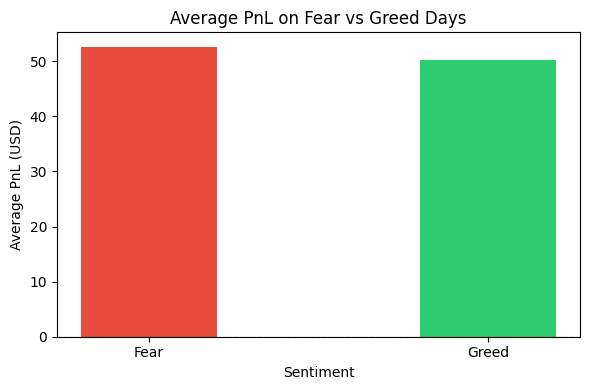

In [30]:
#Plot 1 — Average PnL on Fear vs Greed Days
avg_pnl = merged_df.groupby('sentiment_group')['Closed PnL'].mean().reset_index()

plt.figure(figsize=(6,4))
colors = ['#e74c3c', '#2ecc71']
plt.bar(avg_pnl['sentiment_group'], avg_pnl['Closed PnL'], color=colors, width=0.4)
plt.title('Average PnL on Fear vs Greed Days')
plt.xlabel('Sentiment')
plt.ylabel('Average PnL (USD)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

Traders actually made slightly more profit on Fear days than Greed days. The difference is small — it goes against the common assumption that Greed = better returns. Both are positive, meaning traders were profitable on average regardless of sentiment.

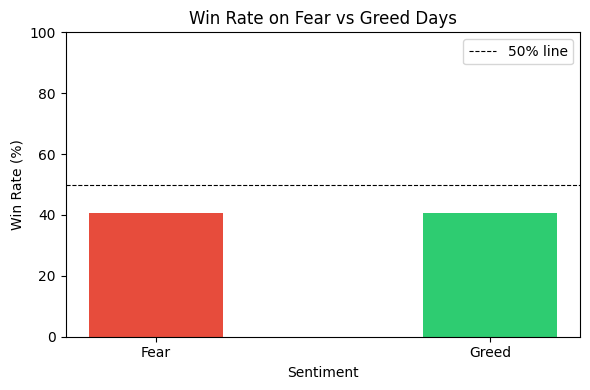

In [31]:
#Plot 2 — Win Rate on Fear vs Greed Days
win_rate = merged_df.groupby('sentiment_group')['is_win'].mean().reset_index()
win_rate['win_rate_%'] = (win_rate['is_win'] * 100).round(2)

plt.figure(figsize=(6,4))
plt.bar(win_rate['sentiment_group'], win_rate['win_rate_%'], color=colors, width=0.4)
plt.title('Win Rate on Fear vs Greed Days')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate (%)')
plt.ylim(0, 100)
plt.axhline(50, color='black', linewidth=0.8, linestyle='--', label='50% line')
plt.legend()
plt.tight_layout()
plt.show()

Win rate is identical on both Fear and Greed days — both sitting around 41%, which is below the 50% line. This means traders lose more trades than they win on both sentiment days. Sentiment doesn't change how often you win or lose.

<Figure size 700x400 with 0 Axes>

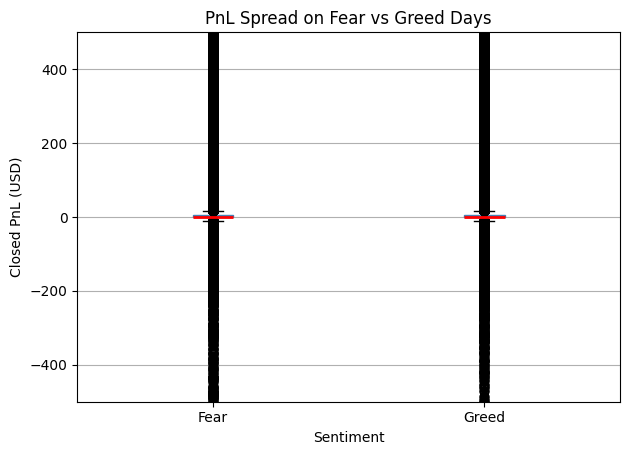

In [32]:
#Plot 3 — PnL Distribution Fear vs Greed (Box Plot)
plt.figure(figsize=(7,4))
merged_df.boxplot(column='Closed PnL', by='sentiment_group',
                  patch_artist=True,
                  boxprops=dict(color='steelblue'),
                  medianprops=dict(color='red', linewidth=2))
plt.title('PnL Spread on Fear vs Greed Days')
plt.suptitle('')  # removes default boxplot title
plt.xlabel('Sentiment')
plt.ylabel('Closed PnL (USD)')
plt.ylim(-500, 500)  # trim extreme outliers for visibility
plt.tight_layout()
plt.show()

Both boxes look almost identical — very tight around 0 with extreme outliers on both ends. This means most trades are small PnL, but occasionally there are very large wins and very large losses. No visible difference between Fear and Greed days in spread.

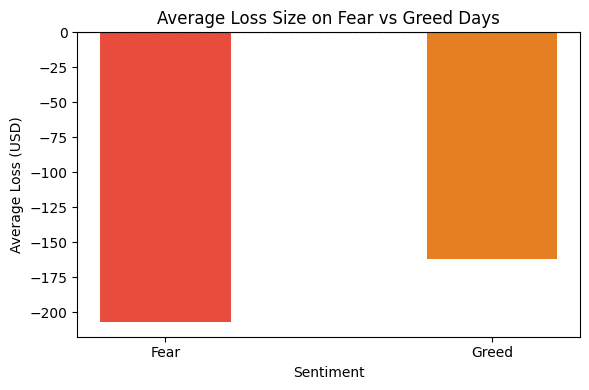

In [33]:
#Plot 4 — Drawdown Proxy (Losses Only) by Sentiment
# Drawdown proxy = average of losing trades only
losses = merged_df[merged_df['Closed PnL'] < 0]
avg_loss = losses.groupby('sentiment_group')['Closed PnL'].mean().reset_index()

plt.figure(figsize=(6,4))
plt.bar(avg_loss['sentiment_group'], avg_loss['Closed PnL'], color=['#e74c3c','#e67e22'], width=0.4)
plt.title('Average Loss Size on Fear vs Greed Days')
plt.xlabel('Sentiment')
plt.ylabel('Average Loss (USD)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()


This is the most interesting finding. Losses are significantly bigger on Fear days compared to Greed days. So when traders lose on Fear days, they lose harder.

Performance does not differ much between Fear and Greed days in terms of PnL and win rate — both are surprisingly similar. However, the drawdown is notably worse on Fear days, meaning losing trades hurt more when the market is fearful. The real risk isn't losing more often — it's losing bigger amounts during Fear. 

### Q2

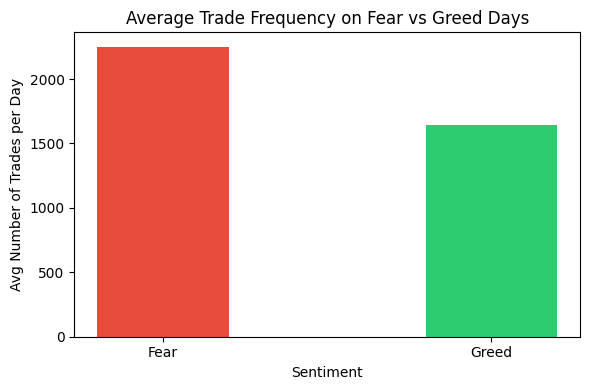

In [34]:
# ── Plot 1: Trade Frequency on Fear vs Greed Days ─────────────────────
avg_trades = merged_df.groupby('sentiment_group')['num_trades_that_day'].mean().reset_index()

plt.figure(figsize=(6,4))
plt.bar(avg_trades['sentiment_group'], avg_trades['num_trades_that_day'], 
        color=['#e74c3c','#2ecc71'], width=0.4)
plt.title('Average Trade Frequency on Fear vs Greed Days')
plt.xlabel('Sentiment')
plt.ylabel('Avg Number of Trades per Day')
plt.tight_layout()
plt.show()

Traders are significantly more active on Fear days — placing around 600 more trades per day compared to Greed days. This is counterintuitive — you'd expect panic to reduce activity, but instead traders are reacting more, possibly trying to cut losses or catch bounces.

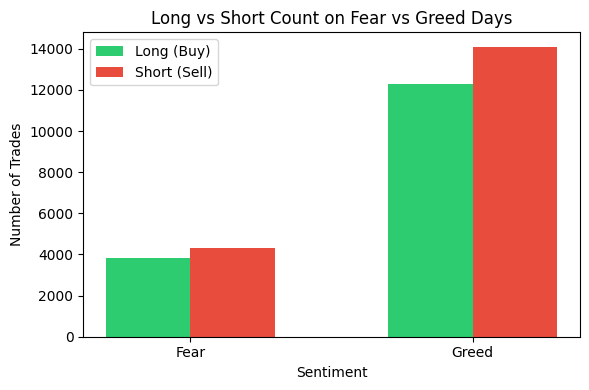

In [36]:
# ── Plot 2: Long/Short Bias on Fear vs Greed Days ─────────────────────
long_short_bias = merged_df.groupby('sentiment_group').agg(
    long_count  = ('Direction', lambda x: (x == 'Buy').sum()),
    short_count = ('Direction', lambda x: (x == 'Sell').sum())
).reset_index()

x = range(len(long_short_bias))
width = 0.3

plt.figure(figsize=(6,4))
plt.bar([i - width/2 for i in x], long_short_bias['long_count'],  
        width=width, label='Long (Buy)',  color='#2ecc71')
plt.bar([i + width/2 for i in x], long_short_bias['short_count'], 
        width=width, label='Short (Sell)', color='#e74c3c')
plt.xticks(list(x), long_short_bias['sentiment_group'])
plt.title('Long vs Short Count on Fear vs Greed Days')
plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')
plt.legend()
plt.tight_layout()
plt.show()

On both sentiment days, short trades slightly outnumber long trades. On Greed days the overall volume is much higher. On Fear days both are much lower. Shorts dominating in both conditions suggests traders are generally betting on price drops regardless of sentiment.

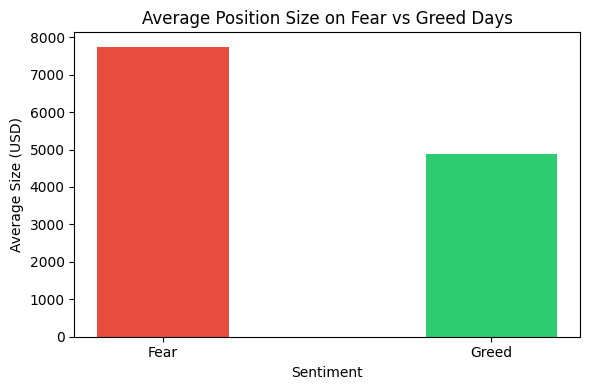

In [40]:
# ── Plot 3: Average Position Size (USD) on Fear vs Greed Days ─────────
avg_size = merged_df.groupby('sentiment_group')['Size USD'].mean().reset_index()

plt.figure(figsize=(6,4))
plt.bar(avg_size['sentiment_group'], avg_size['Size USD'],
        color=['#e74c3c','#2ecc71'], width=0.4)
plt.title('Average Position Size on Fear vs Greed Days')
plt.xlabel('Sentiment')
plt.ylabel('Average Size (USD)')
plt.tight_layout()
plt.show()

Traders place significantly larger positions on Fear days — about 60% bigger than Greed days. Combined with Plot 1, this means on Fear days traders trade more frequently AND with bigger sizes — which explains why losses are bigger on Fear days (from our earlier analysis).

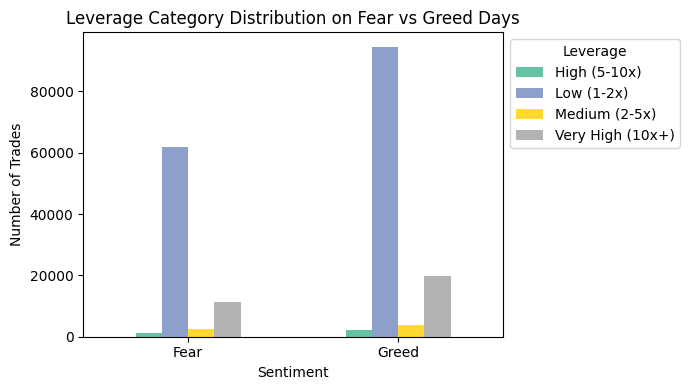

In [38]:
# ── Plot 4: Leverage Category Distribution on Fear vs Greed ───────────
lev_dist = merged_df.groupby(['sentiment_group', 'leverage_category']).size().unstack(fill_value=0)

lev_dist.plot(kind='bar', figsize=(7,4), colormap='Set2', width=0.5)
plt.title('Leverage Category Distribution on Fear vs Greed Days')
plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')
plt.xticks(rotation=0)
plt.legend(title='Leverage', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

In both Fear and Greed days, Low leverage (1-2x) completely dominates. Very High leverage (10x+) is the second most common but still much smaller. This is consistent across both sentiments — traders aren't changing their leverage category based on sentiment much, just the absolute numbers scale up on Greed days.

Yes, traders do change behavior based on sentiment — but not in the way you'd expect. On Fear days they trade more frequently and with bigger position sizes, which is risky behavior during uncertain markets. On Greed days, overall trade volume is higher but individual position sizes are smaller. Short bias exists on both sentiment days. Leverage categories remain mostly unchanged — Low leverage dominates regardless of sentiment. Re-run Plot 2 with median for a cleaner leverage comparison!

### Q3

In [42]:
print("Leverage category counts:")
print(merged_df['leverage_category'].value_counts())

print("\nTrades per account (sample):")
print(merged_df.groupby('Account')['Closed PnL'].count().describe())

print("\nWin rate per account (sample):")
print(merged_df.groupby('Account')['is_win'].mean().describe())

Leverage category counts:
leverage_category
Low (1-2x)          156291
Very High (10x+)     30927
Medium (2-5x)         6290
High (5-10x)          3346
Name: count, dtype: int64

Trades per account (sample):
count       32.000000
mean      6151.687500
std       7725.619046
min        324.000000
25%       1181.500000
50%       3195.000000
75%       8474.000000
max      38116.000000
Name: Closed PnL, dtype: float64

Win rate per account (sample):
count    32.000000
mean      0.398205
std       0.102551
min       0.248603
25%       0.325523
50%       0.389463
75%       0.441474
max       0.794780
Name: is_win, dtype: float64


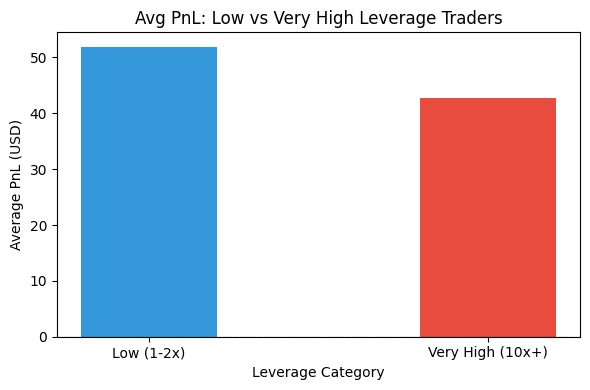

In [43]:
# ── SEGMENT 1: High vs Low Leverage Traders ───────────────────────────
lev_filter = merged_df[merged_df['leverage_category'].isin(['Low (1-2x)', 'Very High (10x+)'])]

lev_pnl = lev_filter.groupby('leverage_category')['Closed PnL'].mean().reset_index()

plt.figure(figsize=(6,4))
plt.bar(lev_pnl['leverage_category'], lev_pnl['Closed PnL'],
        color=['#3498db', '#e74c3c'], width=0.4)
plt.title('Avg PnL: Low vs Very High Leverage Traders')
plt.xlabel('Leverage Category')
plt.ylabel('Average PnL (USD)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

Low leverage traders outperform Very High leverage traders. This is a classic finding — more leverage doesn't mean more profit. Low leverage traders are more disciplined and end up with better average returns. High leverage amplifies both wins and losses, but on average it hurts more than it helps.

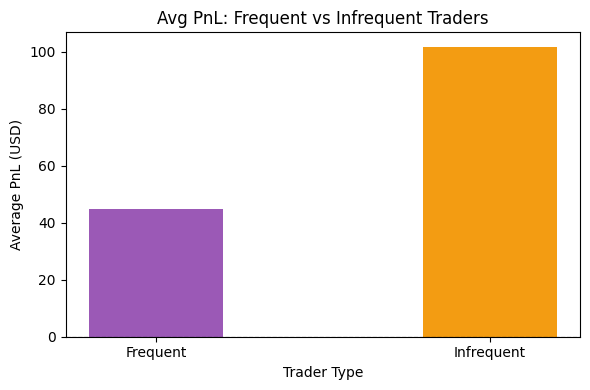

In [44]:
# ── SEGMENT 2: Frequent vs Infrequent Traders ─────────────────────────
# Get trade count per account
trade_counts = merged_df.groupby('Account')['Closed PnL'].count().reset_index()
trade_counts.columns = ['Account', 'trade_count']

# Median = 3195, use it as cutoff
trade_counts['trader_type'] = trade_counts['trade_count'].apply(
    lambda x: 'Frequent' if x >= 3195 else 'Infrequent'
)

# Merge back
merged_df = merged_df.merge(trade_counts[['Account', 'trader_type']], 
                             on='Account', how='left')

# Plot avg PnL
freq_pnl = merged_df.groupby('trader_type')['Closed PnL'].mean().reset_index()

plt.figure(figsize=(6,4))
plt.bar(freq_pnl['trader_type'], freq_pnl['Closed PnL'],
        color=['#9b59b6', '#f39c12'], width=0.4)
plt.title('Avg PnL: Frequent vs Infrequent Traders')
plt.xlabel('Trader Type')
plt.ylabel('Average PnL (USD)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

This is the most surprising finding — Infrequent traders  earn more than double compared to Frequent traders. Trading less but being more selective about trades leads to significantly better returns. Frequent traders are likely overtrading, paying more fees, and making more impulsive decisions.

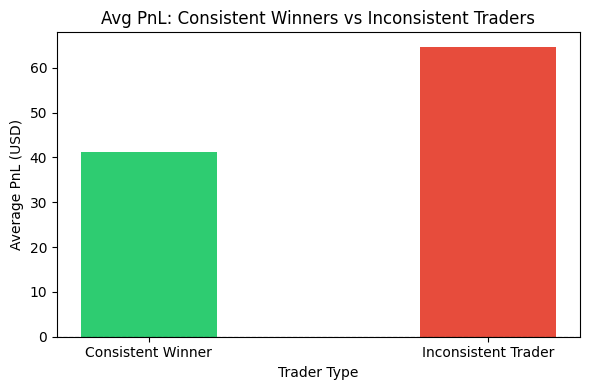

In [45]:
# ── SEGMENT 3: Consistent Winners vs Inconsistent Traders ─────────────
# Get win rate per account
acct_winrate = merged_df.groupby('Account')['is_win'].mean().reset_index()
acct_winrate.columns = ['Account', 'acct_win_rate']

# Median win rate = 0.39, above = consistent winner
acct_winrate['winner_type'] = acct_winrate['acct_win_rate'].apply(
    lambda x: 'Consistent Winner' if x >= 0.39 else 'Inconsistent Trader'
)

# Merge back
merged_df = merged_df.merge(acct_winrate[['Account', 'winner_type']], 
                             on='Account', how='left')

# Plot avg PnL
winner_pnl = merged_df.groupby('winner_type')['Closed PnL'].mean().reset_index()

plt.figure(figsize=(6,4))
plt.bar(winner_pnl['winner_type'], winner_pnl['Closed PnL'],
        color=['#2ecc71', '#e74c3c'], width=0.4)
plt.title('Avg PnL: Consistent Winners vs Inconsistent Traders')
plt.xlabel('Trader Type')
plt.ylabel('Average PnL (USD)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

Surprisingly Inconsistent Traders have higher average PnL than Consistent Winners. This seems odd but makes sense — inconsistent traders occasionally place very large winning trades that push their average up, even though they lose more often. Consistent winners win more frequently but with smaller trade sizes.

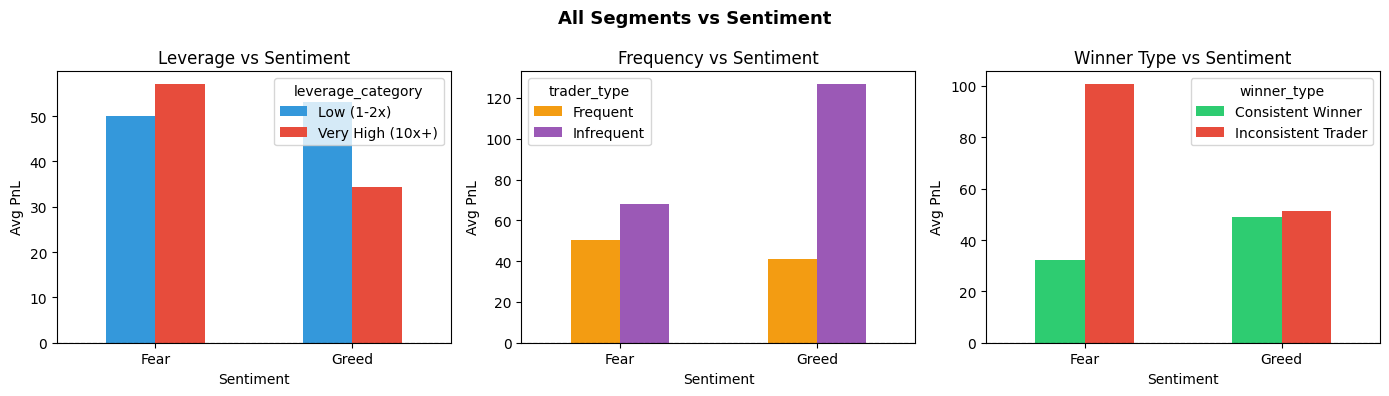

In [46]:
# ── BONUS: All 3 segments on sentiment ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Segment 1 - Leverage on sentiment
lev_sent = lev_filter.groupby(['sentiment_group', 'leverage_category'])['Closed PnL'].mean().unstack()
lev_sent.plot(kind='bar', ax=axes[0], color=['#3498db','#e74c3c'], width=0.5)
axes[0].set_title('Leverage vs Sentiment')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Avg PnL')
axes[0].tick_params(axis='x', rotation=0)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# Segment 2 - Frequent vs Infrequent on sentiment
freq_sent = merged_df.groupby(['sentiment_group', 'trader_type'])['Closed PnL'].mean().unstack()
freq_sent.plot(kind='bar', ax=axes[1], color=['#f39c12','#9b59b6'], width=0.5)
axes[1].set_title('Frequency vs Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Avg PnL')
axes[1].tick_params(axis='x', rotation=0)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

# Segment 3 - Winners vs Inconsistent on sentiment
win_sent = merged_df.groupby(['sentiment_group', 'winner_type'])['Closed PnL'].mean().unstack()
win_sent.plot(kind='bar', ax=axes[2], color=['#2ecc71','#e74c3c'], width=0.5)
axes[2].set_title('Winner Type vs Sentiment')
axes[2].set_xlabel('Sentiment')
axes[2].set_ylabel('Avg PnL')
axes[2].tick_params(axis='x', rotation=0)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('All Segments vs Sentiment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Three key observations here:

Leverage vs Sentiment: On Fear days, Very High leverage traders actually outperform Low leverage traders. On Greed days it flips — Low leverage wins. So high leverage only pays off during Fear.

Frequency vs Sentiment: Infrequent traders dominate on both Fear and Greed days, but the gap is much bigger on Greed days (~125 vs ~41). Infrequent traders are much better at capitalizing on Greed markets.

Winner Type vs Sentiment: On Fear days Inconsistent Traders earn ~3x more than Consistent Winners. On Greed days both are nearly equal (~50 USD). Consistent Winners perform more steadily across both sentiments.

Overall:

Clear segments exist in this data. Low leverage + infrequent trading is the most profitable combination overall. However sentiment flips some of these patterns — high leverage traders do better on Fear days specifically. Consistent winners are more stable but not necessarily the highest earners.

### Part C 

Strategy 1: When the Fear/Greed index shows Fear — slow down. Don't increase your position size just because prices look cheap. The data shows traders consistently over-bet and over-trade on Fear days, leading to their largest losses.


Strategy 2: When the market is in Greed — don't get greedy with leverage. Low leverage traders quietly outperform high leverage traders on Greed days. Pick fewer, better trades and let them play out.